# IAIP Internship — Sales Data Analysis

## Task 1: Sales Data Analysis

### Objective
Analyze sales data to identify sales trends, seasonal patterns, and product performance.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset
Kaggle Sales Data

### Analysis Covered
- Data Cleaning
- Overall Sales Performance
- Product Performance
- Monthly Sales Trends
- Hourly Sales Patterns
- City-wise Sales Performance
- Average Order Value

## 1. Data Cleaning

The dataset was inspected and prepared before analysis.

### Cleaning steps performed
- Removed the unnecessary index column.
- Converted `Order Date` from text format to datetime format.
- Checked for missing values.
- Identified 264 exact duplicate rows and removed them.
- Rechecked the dataset to confirm that no exact duplicate rows remained.
- Repeated `Order ID` values were retained because a single order can contain multiple products.

## 2. Initial Data Exploration

Before performing the analysis, the dataset was loaded and inspected to understand its structure, dimensions, data types, and overall quality.

In [1]:
import pandas as pd

df = pd.read_csv("../data/Sales Data.csv")

df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [2]:
df.shape

(185950, 11)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  str    
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  str    
 6   Purchase Address  185950 non-null  str    
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  str    
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 15.6 MB


In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  int64         
 1   Product           185950 non-null  str           
 2   Quantity Ordered  185950 non-null  int64         
 3   Price Each        185950 non-null  float64       
 4   Order Date        185950 non-null  datetime64[us]
 5   Purchase Address  185950 non-null  str           
 6   Month             185950 non-null  int64         
 7   Sales             185950 non-null  float64       
 8   City              185950 non-null  str           
 9   Hour              185950 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 14.2 MB


In [7]:
df.duplicated().sum()

np.int64(264)

In [8]:
df["Order ID"].duplicated().sum()

np.int64(7513)

In [9]:
df.duplicated().sum()
df["Order ID"].duplicated().sum()

np.int64(7513)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(185686, 10)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()
df.shape
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(185686, 10)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["Sales"].sum()

np.float64(34465537.94)

## 3. Overall Sales Performance

In [18]:
df["Sales"].describe()

count    185686.000000
mean        185.611936
std         333.032118
min           2.990000
25%          11.950000
50%          14.950000
75%         150.000000
max        3400.000000
Name: Sales, dtype: float64

In [19]:
df["Sales"].sum()

np.float64(34465537.94)

## 4. Product Performance Analysis

In [20]:
df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)

Product
AAA Batteries (4-pack)        30986
AA Batteries (4-pack)         27615
USB-C Charging Cable          23931
Lightning Charging Cable      23169
Wired Headphones              20524
Apple Airpods Headphones      15637
Bose SoundSport Headphones    13430
27in FHD Monitor               7541
iPhone                         6847
27in 4K Gaming Monitor         6239
34in Ultrawide Monitor         6192
Google Phone                   5529
Flatscreen TV                  4813
Macbook Pro Laptop             4725
ThinkPad Laptop                4128
20in Monitor                   4126
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64

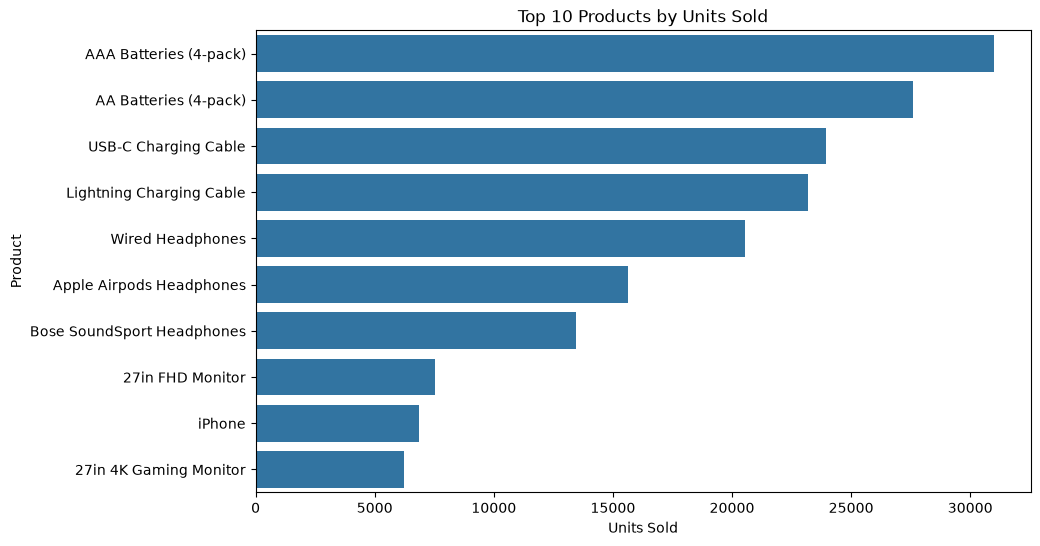

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

top_products = (
    df.groupby("Product")["Quantity Ordered"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.show()

### Top 10 Products by Units Sold — Insight

AAA Batteries (4-pack) and AA Batteries (4-pack) are the most frequently purchased products, with approximately 30,986 and 27,615 units sold respectively. Charging cables and headphones also show strong demand. In contrast, higher-priced products such as monitors and phones have lower unit volumes, suggesting that affordable everyday accessories generate much higher sales volume.

In [22]:
revenue_by_product = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product

Product
Macbook Pro Laptop            8032500.00
iPhone                        4792900.00
ThinkPad Laptop               4127958.72
Google Phone                  3317400.00
27in 4K Gaming Monitor        2433147.61
34in Ultrawide Monitor        2352898.08
Apple Airpods Headphones      2345550.00
Flatscreen TV                 1443900.00
Bose SoundSport Headphones    1342865.70
27in FHD Monitor              1131074.59
Vareebadd Phone                827200.00
20in Monitor                   453818.74
LG Washing Machine             399600.00
LG Dryer                       387600.00
Lightning Charging Cable       346376.55
USB-C Charging Cable           285975.45
Wired Headphones               246082.76
AA Batteries (4-pack)          106041.60
AAA Batteries (4-pack)          92648.14
Name: Sales, dtype: float64

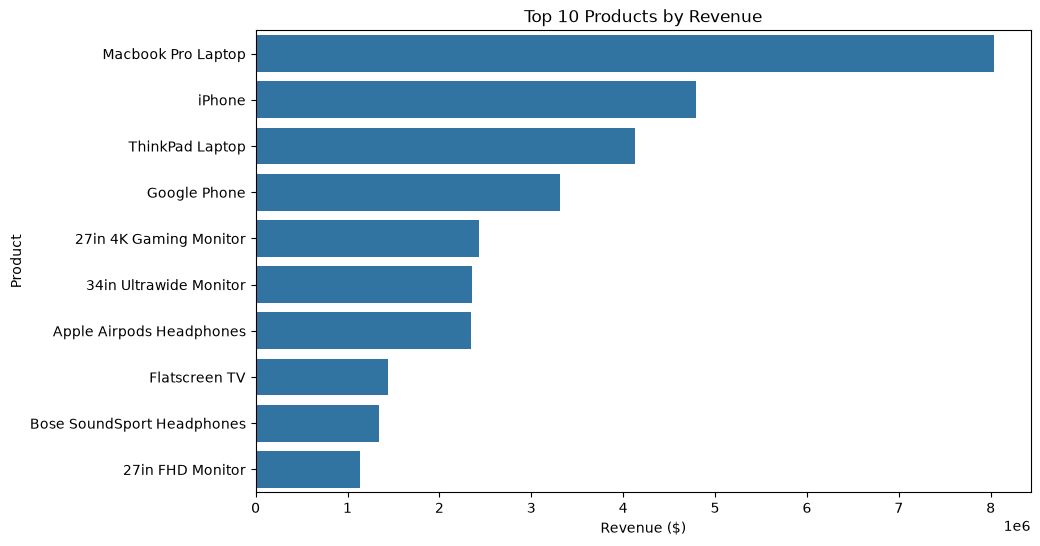

In [23]:
top_revenue_products = revenue_by_product.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_revenue_products.values,
    y=top_revenue_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

plt.show()

### Top 10 Products by Revenue — Insight

Macbook Pro Laptop generates the highest revenue at approximately $8.03 million, followed by the iPhone at $4.79 million and ThinkPad Laptop at $4.13 million. This shows that high-priced electronics can generate significantly more revenue despite having lower unit sales than inexpensive products such as batteries and charging cables.

## 5. Monthly Sales Trends

In [24]:
monthly_sales = (
    df.groupby("Month")["Sales"]
    .sum()
    .sort_index()
)

monthly_sales

Month
1     1821413.16
2     2200078.08
3     2804973.35
4     3389217.98
5     3150616.23
6     2576280.15
7     2646461.32
8     2241083.37
9     2094465.69
10    3734777.86
11    3197875.05
12    4608295.70
Name: Sales, dtype: float64

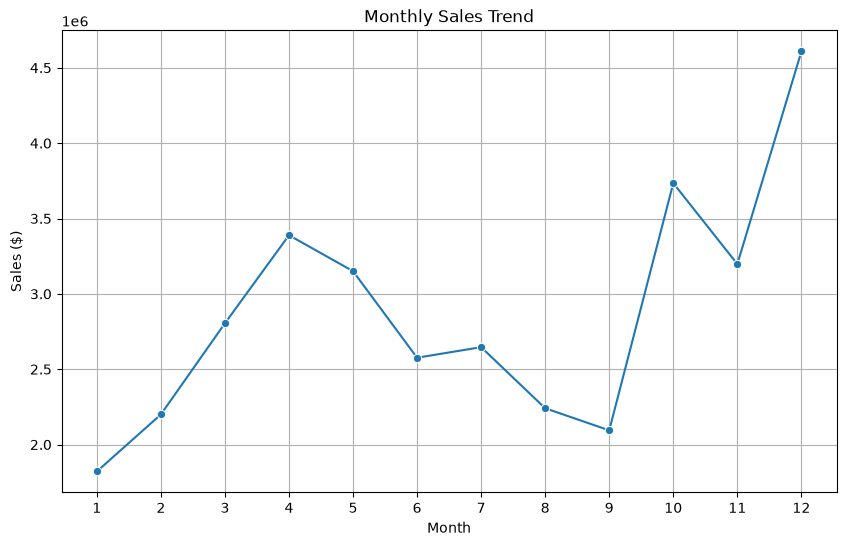

In [26]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

## Monthly Sales Trend — Insight

Sales show a clear year-end surge, with December recording the highest monthly sales (~$4.61M), while January records the lowest (~$1.82M). Sales also rise sharply from September to October, indicating a strong seasonal pattern toward the end of the year.

## 6. Hourly Sales Patterns

This section analyzes how sales vary throughout the day to identify peak purchasing hours and periods of lower customer activity.

In [27]:
hourly_sales = (
    df.groupby("Hour")["Sales"]
    .sum()
    .sort_index()
)

hourly_sales

Hour
0      713548.66
1      460563.90
2      234839.45
3      145742.94
4      162546.07
5      230664.87
6      447963.01
7      744067.32
8     1192309.20
9     1638784.04
10    1942988.08
11    2296619.84
12    2314359.85
13    2152369.98
14    2082513.70
15    1940623.20
16    1902523.20
17    2126553.97
18    2218374.01
19    2411971.14
20    2280784.36
21    2040790.48
22    1606243.85
23    1177792.82
Name: Sales, dtype: float64

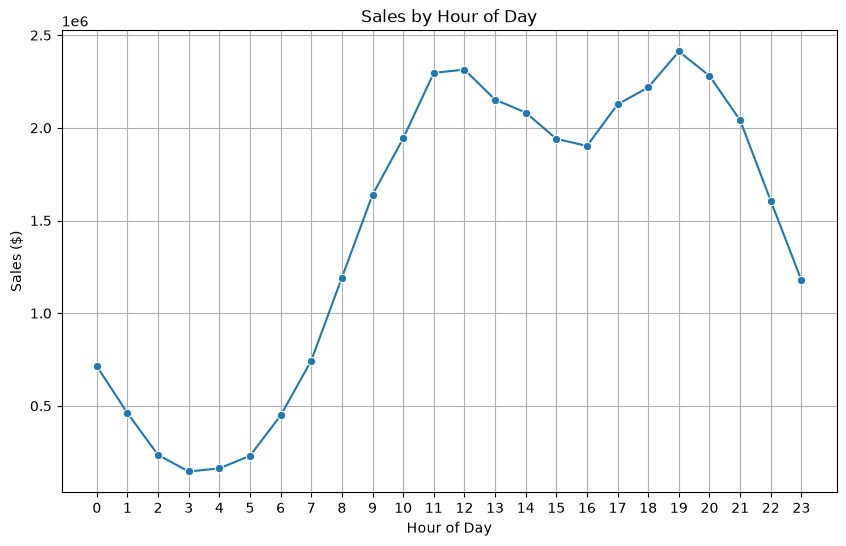

In [28]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    marker="o"
)

plt.title("Sales by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Sales ($)")
plt.xticks(range(0, 24))
plt.grid(True)

plt.show()

## Sales by Hour — Insight

Sales activity is concentrated during daytime and evening hours, with 7 PM recording the highest sales at approximately $2.42M. Sales rise sharply from the morning toward midday and remain relatively strong through the evening, while overnight hours show substantially lower sales.

## 7. City-wise Sales Performance

This section compares total sales across different cities to identify the strongest-performing markets.

In [29]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales

City
San Francisco    8254743.55
Los Angeles      5448304.28
New York City    4661867.14
Boston           3658627.65
Atlanta          2794199.07
Dallas           2765373.96
Seattle          2745046.02
Portland         2319331.94
Austin           1818044.33
Name: Sales, dtype: float64

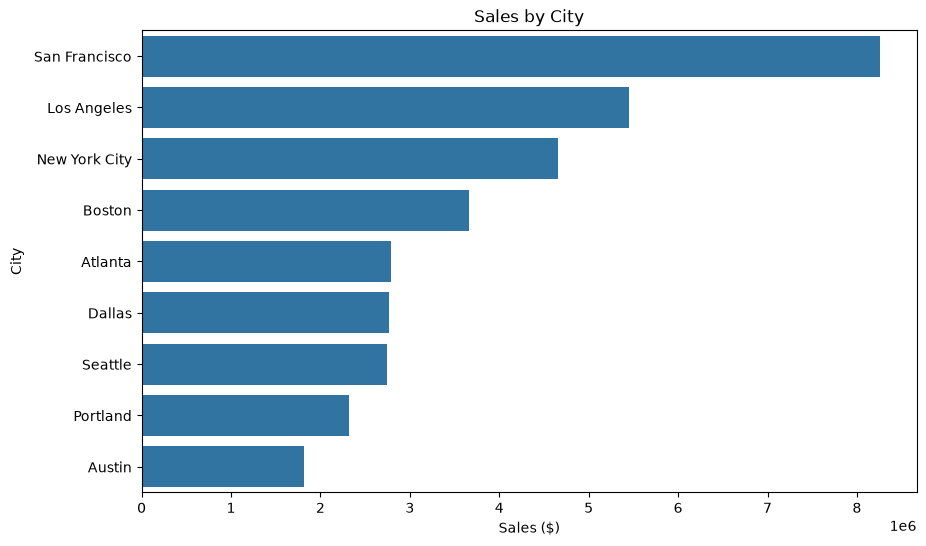

In [30]:
top_city_sales = city_sales.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_city_sales.values,
    y=top_city_sales.index
)

plt.title("Sales by City")
plt.xlabel("Sales ($)")
plt.ylabel("City")

plt.show()

## Sales by City — Insight

San Francisco is the highest-performing city, generating approximately $8.25M in sales, followed by Los Angeles (~$5.45M) and New York City (~$4.66M). This indicates that sales are concentrated in a few major markets, with San Francisco significantly outperforming the other cities.

## 8. Average Order Value

Average Order Value (AOV) measures the average revenue generated by each unique order. It is calculated by dividing total sales revenue by the number of unique orders.

In [31]:
total_revenue = df["Sales"].sum()
total_orders = df["Order ID"].nunique()

average_order_value = total_revenue / total_orders

average_order_value

np.float64(193.15241760397225)

## Average Order Value — Insight

The average order value is approximately $193.15. This means that, across all unique orders in the cleaned dataset, each order generated about $193 in revenue on average.

In [32]:
product_performance = (
    df.groupby("Product")
    .agg(
        Units_Sold=("Quantity Ordered", "sum"),
        Revenue=("Sales", "sum"),
        Average_Price=("Price Each", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

product_performance

,Units_Sold,Revenue,Average_Price
Product,,,
Macbook Pro Laptop,4725,8032500.00,1700.00
iPhone,6847,4792900.00,700.00
ThinkPad Laptop,4128,4127958.72,999.99
Google Phone,5529,3317400.00,600.00
27in 4K Gaming Monitor,6239,2433147.61,389.99
34in Ultrawide Monitor,6192,2352898.08,379.99
Apple Airpods Headphones,15637,2345550.00,150.00
Flatscreen TV,4813,1443900.00,300.00
Bose SoundSport Headphones,13430,1342865.70,99.99


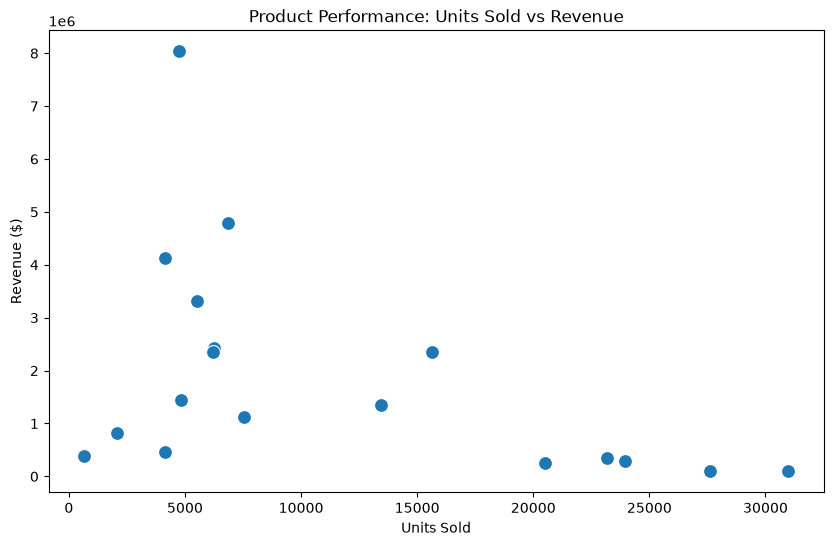

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_performance,
    x="Units_Sold",
    y="Revenue",
    s=100
)

plt.title("Product Performance: Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue ($)")

plt.show()

## Product Performance — Insight

Product sales volume and revenue show very different patterns. Low-priced accessories such as batteries and charging cables sell large quantities but contribute relatively less revenue, while premium products such as laptops and smartphones generate substantially higher revenue despite lower unit volumes.

# 9. Executive Summary

This analysis examined sales data to identify overall sales performance, product performance, seasonal trends, customer purchasing patterns, and geographic sales performance.

The cleaned dataset contained 185,686 records after removing 264 exact duplicate rows. Total recorded sales were approximately $34.47 million, with an average order value of approximately $193.15.

The analysis found that low-priced products such as batteries and charging cables generated the highest sales volumes, while premium products such as the MacBook Pro Laptop and iPhone generated substantially higher revenue. Sales also showed a strong year-end seasonal pattern, with December recording the highest monthly sales. Sales activity was concentrated during daytime and evening hours, with 7 PM being the strongest individual hour. San Francisco was the highest-performing city by total sales.

These findings can help businesses understand product demand, identify high-value products, recognize seasonal opportunities, and focus sales and marketing efforts on stronger markets and purchasing periods.

# 10. Key Findings

### 1. Overall Sales Performance
- Total recorded sales were approximately **$34.47 million**.
- The average order value was approximately **$193.15**.

### 2. Product Performance
- **AAA Batteries (4-pack)** had the highest unit sales, with approximately **30,986 units** sold.
- **MacBook Pro Laptop** generated the highest revenue, at approximately **$8.03 million**.
- High-volume products such as batteries and charging cables do not necessarily generate the highest revenue because of their lower prices.

### 3. Seasonal Sales Trends
- **December** recorded the highest monthly sales at approximately **$4.61 million**.
- **January** recorded the lowest monthly sales at approximately **$1.82 million**.
- Sales increased significantly toward the end of the year, indicating a strong seasonal pattern.

### 4. Hourly Sales Patterns
- **7 PM** was the strongest individual sales hour, generating approximately **$2.42 million**.
- Sales were generally stronger during daytime and evening hours than during overnight hours.

### 5. Geographic Performance
- **San Francisco** was the highest-performing city, generating approximately **$8.25 million** in sales.
- Los Angeles and New York City followed as the next strongest markets.

# 11. Business Recommendations

Based on the analysis, the following recommendations can be considered:

1. **Focus on high-revenue products:** Premium products such as laptops and smartphones contribute significantly to total revenue and should receive appropriate inventory and marketing attention.

2. **Use high-volume products strategically:** Batteries and charging cables have strong unit demand and can be used for bundles, cross-selling, and promotional offers.

3. **Prepare for seasonal demand:** Sales increase significantly toward the end of the year, especially in December. Inventory and marketing resources should be planned in advance for this period.

4. **Optimize marketing timing:** Since sales are strongest during daytime and evening hours, promotional campaigns can be prioritized around these higher-activity periods.

5. **Focus on high-performing markets:** San Francisco, Los Angeles, and New York City generate substantial sales and can receive greater attention in regional marketing and inventory planning.

# 12. Conclusion

The sales data analysis provided useful insights into overall revenue, product performance, seasonal trends, purchasing hours, and geographic sales patterns. The analysis showed that high-volume products and high-revenue products are not always the same, while sales also demonstrated a strong increase toward the end of the year. These findings can support better inventory planning, marketing decisions, product prioritization, and regional sales strategies.